In [44]:


!pip install -q ranx

!git clone https://github.com/TalentCLEF/talentclef26_evaluation_script.git /content/talentclef26_evaluation_script

%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

fatal: destination path '/content/talentclef26_evaluation_script' already exists and is not an empty directory.
env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


In [45]:


import os, gc, math, random, warnings, subprocess
import glob
import re
import numpy as np
import pandas as pd

import gc

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import time

import torch
import torch.nn.functional as F
from torch import nn
from torch.nn import MSELoss
from torch.optim import AdamW
from torch.utils.data import Dataset

from pathlib import Path
from tqdm.auto import tqdm

from transformers import (
    AutoModel,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

gc.collect()
torch.cuda.empty_cache()

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-40GB


In [46]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/A.zip" /content/
!unzip -q /content/A.zip -d /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/A/Development/en/corpus/10004? [y]es, [n]o, [A]ll, [N]one, [r]ename: None


In [47]:


SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

NUM_GPUS = torch.cuda.device_count()
print(f"GPUs available: {NUM_GPUS}")
for i in range(NUM_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Primary device: {DEVICE}")

GPUs available: 1
  GPU 0: NVIDIA A100-SXM4-40GB
Primary device: cuda


In [48]:


STUDENT_MODEL = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
TEACHER_MODEL = "jjzha/jobbert-base-cased"
LANGUAGE = "en"
DISTILL_WEIGHT = 0.0 if LANGUAGE == "es" else 0.3
DISTILL_TEMP = 2.0
MODEL_NAME = TEACHER_MODEL

OUTPUT_DIR = "/content/jobbert_output"
LOGGING_DIR = "/content/jobbert_logs"


TRAIN_CSV = "/content/A/Training/normalization/job_applicant_dataset.csv"
DEV_BASE = "/content/A/Development/en"
CORPUS_DIR = os.path.join(DEV_BASE, "corpus")
QUERY_DIR = os.path.join(DEV_BASE, "queries")
QRELS_FILE = os.path.join(DEV_BASE, "qrels.tsv")


MAX_LEN = 512
TRAIN_BATCH = 8
EVAL_BATCH = 8
GRAD_ACCUM = 4
NUM_EPOCHS = 4
LR = 1e-5
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01


PROJ_DIM = 256
TAU_INIT = -2.62
SKILL_WEIGHT = 0.25


HNM_TOPK = 50
HNM_NEGATIVES = 1
HNM_EPOCHS = 4
HNM_BATCH = 16
HNM_ROUNDS = 2

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)

In [49]:


print("Loading training CSV …")
df_train = pd.read_csv(TRAIN_CSV)
print(f"Shape : {df_train.shape}")
print(df_train.head(3))
print("\nColumn dtypes:\n", df_train.dtypes)
print("\nValue counts (label):\n", df_train.iloc[:, -1].value_counts())

Loading training CSV …
Shape : (10000, 9)
  Job Applicant Name  Age  Gender             Race   Ethnicity  \
0       Daisuke Mori   29    Male  Mongoloid/Asian  Vietnamese   
1     Taichi Shimizu   31    Male  Mongoloid/Asian    Filipino   
2       Sarah Martin   46  Female  White/Caucasian       Dutch   

                                              Resume          Job Roles  \
0  Daisuke Mori\n243 Hill Street\nAmsterdam, Nort...      Fitness Coach   
1  Taichi Shimizu\n108 Market Street\nCape Town, ...          Physician   
2  Sarah Martin\n10 Lincoln Avenue\nMumbai, Mahar...  Financial Analyst   

                                     Job Description  Best Match  
0  Fitness Coach\n\nA Fitness Coach is responsibl...           0  
1  Physician\n\nDiagnose and treat illnesses, pre...           0  
2  Financial Analyst\n\nAs a Financial Analyst, y...           0  

Column dtypes:
 Job Applicant Name    object
Age                    int64
Gender                object
Race                

In [50]:


text_a_col = "Job Description"
text_b_col = "Resume"
label_col = "Best Match"

print(f"Text A: {text_a_col}")
print(f"Text B: {text_b_col}")
print(f"Label: {label_col}")

df_train[label_col] = df_train[label_col].astype(int)
assert set(df_train[label_col].unique()).issubset({0, 1}), \
    "Label column must contain only 0 and 1!"

Text A: Job Description
Text B: Resume
Label: Best Match


In [51]:


print(f"\nLoading student tokenizer: {STUDENT_MODEL} …")
tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL)

print(f"Loading teacher tokenizer: {TEACHER_MODEL} …")
teacher_tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL)


Loading student tokenizer: sentence-transformers/paraphrase-multilingual-mpnet-base-v2 …
Loading teacher tokenizer: jjzha/jobbert-base-cased …


In [52]:


print(f"\nLoading frozen teacher: {TEACHER_MODEL} …")
teacher_model = AutoModel.from_pretrained(TEACHER_MODEL).to(DEVICE)

for param in teacher_model.parameters():
    param.requires_grad = False

teacher_model.eval()
print(f"Teacher parameters (frozen): {sum(p.numel() for p in teacher_model.parameters()):,}")


def encode_with_teacher(raw_texts, teacher_model, teacher_tokenizer,
                         max_len=256, device=DEVICE):
    enc = teacher_tokenizer(
        raw_texts,
        max_length = max_len,
        truncation = True,
        padding = True,
        return_tensors = "pt",
        return_token_type_ids = True
    ).to(device)
    with torch.no_grad():
        out = teacher_model(**enc)
    emb = mean_pooling(out, enc["attention_mask"])
    return F.normalize(emb, p=2, dim=-1)


Loading frozen teacher: jjzha/jobbert-base-cased …


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Teacher parameters (frozen): 108,310,272


In [53]:


def read_text_file(folder, file_id):
    path = os.path.join(folder, str(file_id))
    if not os.path.exists(path):
        return ""
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return f.read().strip()

def extract_skills(text):
    if not text:
        return set()
    t = text

    heading_pat = (
        r"(?is)(?:^|\n)\s*"
        r"(?:skills|required skills|"
        r"habilidades(?: requeridas?)?|"
        r"competencias|destrezas)"
        r"\s*[:\-\n]+(.*?)(?:\n\s*\n|\n---|$)"
    )
    m = re.search(heading_pat, t)
    block = None

    if m:
        block = m.group(1)
    else:
        lines = t.splitlines()
        for i, line in enumerate(lines):
            if re.search(
                r"(?i)^\s*(skills|required skills|"
                r"habilidades|competencias|destrezas)\b",
                line
            ):
                block = "\n".join(lines[i+1 : i+7])
                break

    if not block:
        return set()

    parts = re.split(r"[\n,•\-\t]+", block)
    tokens = set()
    for p in parts:
        s = p.strip()
        if not s:
            continue
        s = re.sub(r"[^\w &/+-]+$", "", s)
        s = re.sub(r"^[^\w]+", "", s)
        s = " ".join(s.lower().split())
        if len(s) > 1:
            tokens.add(s)

    return tokens

In [54]:


print("\nLoading qrels …")
qrels = pd.read_csv(
    QRELS_FILE, sep="\t", header=None,
    names=["q_id", "iter", "c_id", "relevance"]
)
print(f"qrels shape: {qrels.shape}")
print(qrels.head())


Loading qrels …
qrels shape: (472, 4)
    q_id  iter   c_id  relevance
0  36044     0  13884          1
1  39060     0   9516          1
2  39060     0  12097          1
3  32447     0  13882          1
4  39060     0   6533          1


In [55]:


print("\nLoading all query files …")
query_dict = {}
query_skills = {}
for fpath in sorted(glob.glob(os.path.join(QUERY_DIR, "*"))):
    fid = os.path.basename(fpath)
    txt = read_text_file(QUERY_DIR, fid)
    query_dict[fid] = txt
    query_skills[fid] = extract_skills(txt)
print(f"  Queries found: {len(query_dict)}")

print("Loading all corpus files …")
corpus_dict = {}
corpus_skills = {}
for fpath in sorted(glob.glob(os.path.join(CORPUS_DIR, "*"))):
    fid = os.path.basename(fpath)
    txt = read_text_file(CORPUS_DIR, fid)
    corpus_dict[fid] = txt
    corpus_skills[fid] = extract_skills(txt)
print(f"  Corpus elements found: {len(corpus_dict)}")

positive_set = set(zip(
    qrels["q_id"].astype(str),
    qrels["c_id"].astype(str)
))

print("\nBuilding all (query × corpus) pairs …")
dev_records = []
for q_id, q_text in tqdm(query_dict.items(), desc="Queries"):
    for c_id, c_text in corpus_dict.items():
        dev_records.append({
            "q_id": q_id,
            "c_id": c_id,
            "query_text": q_text,
            "corpus_text": c_text,
            "relevance": 1 if (q_id, c_id) in positive_set else 0,
        })

df_dev = pd.DataFrame(dev_records)

print(f"Positives: {(df_dev['relevance']==1).sum()}")
print(f"Negatives: {(df_dev['relevance']==0).sum()}")


Loading all query files …
  Queries found: 10
Loading all corpus files …
  Corpus elements found: 472

Building all (query × corpus) pairs …


Queries:   0%|          | 0/10 [00:00<?, ?it/s]

Positives: 472
Negatives: 4248


In [56]:


class SingleTextDataset(Dataset):
    def __init__(self, texts, ids, tokenizer, max_len):
        self.texts = texts
        self.ids = ids
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            " ".join(str(self.texts[idx]).split()[:384]),
            max_length=self.max_len,
            truncation=True,
            padding=False,
            return_token_type_ids=False,
        )
        return enc


def mean_pooling(model_output, attention_mask):
    token_emb = model_output.last_hidden_state
    mask_exp = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
    return torch.sum(token_emb * mask_exp, 1) / torch.clamp(mask_exp.sum(1), min=1e-9)


class TripletDataset(Dataset):
    def __init__(self, df, tokenizer, max_len,
                 q_col, pos_col, neg_col):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.q_col = q_col
        self.pos_col = pos_col
        self.neg_col = neg_col
        self.data = df.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def _enc(self, text):
        tokens = self.tokenizer(
            str(text),
            max_length = 512,
            truncation = True,
            padding = False,
            return_tensors = None
        )

        input_ids = tokens["input_ids"]
        attn_mask = tokens["attention_mask"]

        stride = 256
        max_chunk = 512
        chunks_ids, chunks_mask = [], []

        for start in range(0, max(1, len(input_ids)), stride):
            end = start + max_chunk
            cids = input_ids[start:end]
            cmsk = attn_mask[start:end]
            pad_len = max_chunk - len(cids)
            chunks_ids.append(cids  + [self.tokenizer.pad_token_id] * pad_len)
            chunks_mask.append(cmsk + [0] * pad_len)
            if end >= len(input_ids):
                break

        return {
            "input_ids": torch.tensor(chunks_ids,  dtype=torch.long),
            "attention_mask": torch.tensor(chunks_mask, dtype=torch.long)
        }

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        q_enc = self._enc(row[self.q_col])
        p_enc = self._enc(row[self.pos_col])
        n_enc = self._enc(row[self.neg_col])

        return {
            "q_input_ids": q_enc["input_ids"],
            "q_attention_mask": q_enc["attention_mask"],
            "p_input_ids": p_enc["input_ids"],
            "p_attention_mask": p_enc["attention_mask"],
            "n_input_ids": n_enc["input_ids"],
            "n_attention_mask": n_enc["attention_mask"],
            "q_raw": str(row[self.q_col]),
            "p_raw": str(row[self.pos_col])
        }


def triplet_collate_fn(batch):
    def pad_chunks(tensors):
        max_chunks = max(t.size(0) for t in tensors)
        padded = []
        for t in tensors:
            pad = torch.zeros(max_chunks - t.size(0), t.size(1), dtype=t.dtype)
            padded.append(torch.cat([t, pad], dim=0))
        return torch.stack(padded)

    return {
        "q_input_ids": pad_chunks([b["q_input_ids"]      for b in batch]),
        "q_attention_mask": pad_chunks([b["q_attention_mask"]  for b in batch]),
        "p_input_ids": pad_chunks([b["p_input_ids"]       for b in batch]),
        "p_attention_mask": pad_chunks([b["p_attention_mask"]  for b in batch]),
        "n_input_ids": pad_chunks([b["n_input_ids"]       for b in batch]),
        "n_attention_mask": pad_chunks([b["n_attention_mask"]  for b in batch]),
        "q_raw": [b["q_raw"] for b in batch],
        "p_raw": [b["p_raw"] for b in batch]
    }

In [57]:


NUM_CROSS_ROLE_NEGS = 1

positives = df_train[df_train[label_col] == 1].reset_index(drop=True)
negatives = df_train[df_train[label_col] == 0].reset_index(drop=True)

random.seed(SEED)

neg_by_role = {}
for _, row in negatives.iterrows():
    role = str(row.get("Job Roles", "unknown"))
    neg_by_role.setdefault(role, []).append(row[text_b_col])

all_neg_texts = negatives[text_b_col].tolist()
all_roles = list(neg_by_role.keys())

triplets = []
for _, row in positives.iterrows():
    query_role = str(row.get("Job Roles", "unknown"))

    other_roles = [r for r in all_roles if r != query_role]
    if other_roles:
        neg_role = random.choice(other_roles)
        neg_pool = neg_by_role[neg_role]
    else:
        neg_pool = all_neg_texts

    neg_text = random.choice(neg_pool)
    triplets.append({
        "query": row[text_a_col],
        "positive": row[text_b_col],
        "negative": neg_text
    })

df_triplets = pd.DataFrame(triplets)

df_trip_train, df_trip_val = train_test_split(
    df_triplets, test_size=0.1, random_state=SEED
)
print(f"Triplet train : {len(df_trip_train)}")
print(f"Triplet val   : {len(df_trip_val)}")

train_dataset = TripletDataset(df_trip_train, tokenizer, MAX_LEN,
                                "query", "positive", "negative")
val_dataset = TripletDataset(df_trip_val,   tokenizer, MAX_LEN,
                              "query", "positive", "negative")
data_collator = triplet_collate_fn

Triplet train : 4365
Triplet val   : 485


In [58]:


class BiEncoder(nn.Module):
    def __init__(self, student_model_name, proj_dim=256,
                 tau_init=0.05, dropout_p=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(student_model_name)
        self.embed_dim = self.encoder.config.hidden_size

        self.proj = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(self.embed_dim, proj_dim),
            nn.LayerNorm(proj_dim)
        )
        self.tau = nn.Parameter(torch.tensor(tau_init))

    def encode(self, input_ids, attention_mask):
        B, num_chunks, seq_len = input_ids.size()
        ids_flat = input_ids.view(B * num_chunks, seq_len)
        mask_flat = attention_mask.view(B * num_chunks, seq_len)

        out = self.encoder(input_ids=ids_flat, attention_mask=mask_flat)
        emb_flat = mean_pooling(out, mask_flat)
        emb_flat = emb_flat.view(B, num_chunks, -1)

        chunk_mask = attention_mask.sum(dim=-1).gt(0).float()
        chunk_mask_exp = chunk_mask.unsqueeze(-1)
        emb = (emb_flat * chunk_mask_exp).sum(dim=1) / \
               chunk_mask_exp.sum(dim=1).clamp(min=1e-9)

        emb = self.proj(emb)
        return F.normalize(emb, p=2, dim=-1)

    def get_temp(self):
        return F.softplus(self.tau)

    def forward(self, q_input_ids, q_attention_mask,
                p_input_ids, p_attention_mask,
                n_input_ids, n_attention_mask):
        q_emb = self.encode(q_input_ids, q_attention_mask)
        p_emb = self.encode(p_input_ids, p_attention_mask)
        n_emb = self.encode(n_input_ids, n_attention_mask)
        return q_emb, p_emb, n_emb


model = BiEncoder(STUDENT_MODEL, proj_dim=PROJ_DIM, tau_init=TAU_INIT).to(DEVICE)

_m = model.module if hasattr(model, "module") else model
print(f"Student encoder    : {STUDENT_MODEL}")
print(f"Teacher encoder    : {TEACHER_MODEL} (frozen)")
print(f"Bi-encoder params  : {sum(p.numel() for p in model.parameters()):,}")
print(f"Temperature        : {_m.get_temp().item():.4f}")
print(f"Projection dim     : {PROJ_DIM}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Student encoder    : sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Teacher encoder    : jjzha/jobbert-base-cased (frozen)
Bi-encoder params  : 278,831,617
Temperature        : 0.0703
Projection dim     : 256


In [59]:


def compute_metrics(eval_pred):

    return {}

In [60]:


steps_per_epoch = math.ceil(len(train_dataset) / (TRAIN_BATCH * max(NUM_GPUS, 1) * GRAD_ACCUM))
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

os.environ["TENSORBOARD_LOGGING_DIR"] = LOGGING_DIR

training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    logging_dir = LOGGING_DIR,


    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = TRAIN_BATCH,
    per_device_eval_batch_size = EVAL_BATCH,
    gradient_accumulation_steps = GRAD_ACCUM,


    learning_rate = LR,
    weight_decay = WEIGHT_DECAY,
    warmup_steps = warmup_steps,
    lr_scheduler_type = "cosine",
    max_grad_norm = 1.0,


    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "eval_loss",
    greater_is_better = False,
    remove_unused_columns = False,
    dataloader_num_workers = 4,


    report_to = "none",


    fp16 = False,
    bf16 = True,
    seed = SEED,


    disable_tqdm = False
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [61]:


class CrossLingualJobBERTTrainer(Trainer):
    def _remove_unused_columns(self, dataset, description=None):
        return dataset

    def create_optimizer(self):
        _model = self.model.module if hasattr(self.model, "module") else self.model
        encoder = _model.encoder
        proj = _model.proj
        no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias"}
        base_lr = self.args.learning_rate
        decay_factor = 0.9
        num_layers = encoder.config.num_hidden_layers
        param_groups = []

        for name, param in proj.named_parameters():
            param_groups.append({
                "params": [param],
                "lr": base_lr * 10,
                "weight_decay": 0.0 if any(nd in name for nd in no_decay) else 0.01
            })

        for layer_idx in range(num_layers - 1, -1, -1):
            layer_lr = base_lr * (decay_factor ** (num_layers - 1 - layer_idx))
            for name, param in encoder.encoder.layer[layer_idx].named_parameters():
                param_groups.append({
                    "params": [param],
                    "lr": layer_lr,
                    "weight_decay": 0.0 if any(nd in name for nd in no_decay) else 0.01
                })

        embed_lr = base_lr * (decay_factor ** num_layers)
        for name, param in encoder.embeddings.named_parameters():
            param_groups.append({
                "params": [param],
                "lr": embed_lr,
                "weight_decay": 0.0 if any(nd in name for nd in no_decay) else 0.01
            })

        self.optimizer = AdamW(param_groups)
        return self.optimizer

    def prediction_step(self, model, inputs, prediction_loss_only,
                        ignore_keys=None):
        model.eval()
        with torch.no_grad():
            result = self.compute_loss(model, inputs, return_outputs=True)
            loss = result[0]
        return (loss.detach(), None, None)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        _model = model.module if hasattr(model, "module") else model

        q_emb, p_emb, n_emb = model(
            q_input_ids = inputs["q_input_ids"],
            q_attention_mask = inputs["q_attention_mask"],
            p_input_ids = inputs["p_input_ids"],
            p_attention_mask = inputs["p_attention_mask"],
            n_input_ids = inputs["n_input_ids"],
            n_attention_mask = inputs["n_attention_mask"]
        )

        tau = _model.get_temp()
        B = q_emb.size(0)
        labels = torch.arange(B).to(q_emb.device)

        sim_matrix = torch.mm(q_emb, p_emb.T) / tau
        ce_loss = F.cross_entropy(sim_matrix, labels, label_smoothing=0.05)

        margin_loss = F.triplet_margin_loss(
            q_emb, p_emb, n_emb, margin=0.2, p=2
        )

        q_raw = inputs.get("q_raw", None)
        p_raw = inputs.get("p_raw", None)

        if q_raw is not None and p_raw is not None:
            teacher_q = encode_with_teacher(
                q_raw, teacher_model, teacher_tokenizer,
                device=q_emb.device
            )
            teacher_p = encode_with_teacher(
                p_raw, teacher_model, teacher_tokenizer,
                device=p_emb.device
            )

            teacher_sim = torch.mm(teacher_q, teacher_p.T) / DISTILL_TEMP
            teacher_probs = F.softmax(teacher_sim, dim=-1)

            student_sim = torch.mm(q_emb, p_emb.T) / DISTILL_TEMP
            student_log_probs = F.log_softmax(student_sim, dim=-1)

            distill_loss = F.kl_div(
                student_log_probs, teacher_probs,
                reduction="batchmean"
            )
        else:
            distill_loss = torch.tensor(0.0, device=q_emb.device)

        loss = (ce_loss
                + 0.1 * margin_loss
                + DISTILL_WEIGHT * distill_loss)

        return (loss, (q_emb, p_emb, n_emb)) if return_outputs else loss


trainer = CrossLingualJobBERTTrainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    data_collator = triplet_collate_fn,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
)

In [62]:


print("\n" + "="*60)
print("  Starting JobBERT fine-tuning …")
print("="*60)

train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("\nTraining summary:")
print(train_result.metrics)



  Starting JobBERT fine-tuning …


Epoch,Training Loss,Validation Loss
1,No log,0.348039
2,No log,0.317234
3,No log,0.314624
4,0.368641,0.313819



Training summary:
{'train_runtime': 480.2749, 'train_samples_per_second': 36.354, 'train_steps_per_second': 1.141, 'total_flos': 0.0, 'train_loss': 0.36261985771847466, 'epoch': 4.0}


In [63]:


def encode_texts(text_dict, tokenizer, model, max_len,
                 batch_size=16, desc="Encoding"):
    ids = list(text_dict.keys())
    texts = [str(text_dict[k]) if text_dict[k] is not None else "" for k in ids]

    _model = model.module if hasattr(model, "module") else model
    _model.eval()

    def _enc_single(text):
        tokens = tokenizer(
            text,
            max_length = 512,
            truncation = True,
            padding = False,
            return_tensors = None
        )

        iids = tokens["input_ids"]
        amsk = tokens["attention_mask"]
        stride, max_chunk = 256, 512
        c_ids, c_msk = [], []
        for start in range(0, max(1, len(iids)), stride):
            end = start + max_chunk
            ci = iids[start:end]
            cm = amsk[start:end]
            pad_len = max_chunk - len(ci)
            c_ids.append(ci + [tokenizer.pad_token_id] * pad_len)
            c_msk.append(cm + [0] * pad_len)
            if end >= len(iids):
                break
        return (torch.tensor(c_ids, dtype=torch.long),
                torch.tensor(c_msk, dtype=torch.long))

    embeddings = {}
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=desc):
            batch_ids = ids[i : i + batch_size]
            batch_texts = texts[i : i + batch_size]
            enc_list = [_enc_single(t) for t in batch_texts]

            max_chunks = max(e[0].size(0) for e in enc_list)
            ids_batch, mask_batch = [], []
            for eids, emsk in enc_list:
                pad = torch.zeros(
                    max_chunks - eids.size(0), 512, dtype=torch.long
                )
                ids_batch.append(torch.cat([eids, pad], dim=0))
                mask_batch.append(torch.cat([emsk, pad], dim=0))

            ids_t = torch.stack(ids_batch).to(DEVICE)
            mask_t = torch.stack(mask_batch).to(DEVICE)
            embs = _model.encode(ids_t, mask_t)
            for k, emb in zip(batch_ids, embs.cpu().numpy()):
                embeddings[str(k)] = emb

    return embeddings


print("\nEncoding queries …")
query_embeddings = encode_texts(query_dict,  tokenizer, model, MAX_LEN, desc="Queries")
print("Encoding corpus …")
corpus_embeddings = encode_texts(corpus_dict, tokenizer, model, MAX_LEN, desc="Corpus")























Encoding queries …


Queries:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding corpus …


Corpus:   0%|          | 0/30 [00:00<?, ?it/s]

In [64]:


def iterative_hard_negative_mining(model, tokenizer, df_trip_train, corpus_dict, query_dict,
                                   rounds=2, topk=50, negatives_per_pos=1, epochs=3, batch_size=16):

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    for r in range(rounds):
        print(f"\nHNM Round {r+1}/{rounds}")

        unique_queries = df_trip_train['query'].unique().tolist()
        current_q_dict = {str(i): q_text for i, q_text in enumerate(unique_queries)}

        p_ids_ordered = list(corpus_dict.keys())
        p_texts_ordered = [corpus_dict[pid] for pid in p_ids_ordered]
        current_p_dict = {str(i): t for i, t in enumerate(p_texts_ordered)}

        print("Encoding current state for mining...")
        q_embs_dict = encode_texts(current_q_dict, tokenizer, model, MAX_LEN, batch_size=batch_size)
        p_embs_dict = encode_texts(current_p_dict, tokenizer, model, MAX_LEN, batch_size=batch_size)

        valid_q_ids = [str(i) for i in range(len(unique_queries)) if str(i) in q_embs_dict]
        valid_p_ids = [str(i) for i in range(len(p_texts_ordered)) if str(i) in p_embs_dict]

        if len(valid_q_ids) != len(unique_queries):
            print(f"Warning: Missing {len(unique_queries) - len(valid_q_ids)} queries in encoding!")

        Q = np.stack([q_embs_dict[k] for k in valid_q_ids])
        P = np.stack([p_embs_dict[k] for k in valid_p_ids])

        active_unique_queries = [current_q_dict[k] for k in valid_q_ids]
        qtext_to_idx = {q_text: i for i, q_text in enumerate(active_unique_queries)}

        active_p_texts = [current_p_dict[k] for k in valid_p_ids]

        sim = Q @ P.T

        qtext_to_idx = {q_text: i for i, q_text in enumerate(unique_queries)}

        pos_per_q = {}
        for _, row in df_trip_train.iterrows():
            pos_per_q.setdefault(row['query'], set()).add(row['positive'])

        hard_triplets = []
        for _, row in df_trip_train.iterrows():
            qtext = row['query']
            ptext = row['positive']

            qi = qtext_to_idx[qtext]
            sims = sim[qi]

            top_idxs = np.argsort(-sims)[:topk]

            selected_negs = []
            for idx in top_idxs:
                cand_text = p_texts_ordered[idx]

                if cand_text == ptext or cand_text in pos_per_q.get(qtext, set()):
                    continue

                selected_negs.append(cand_text)
                if len(selected_negs) >= negatives_per_pos:
                    break

            if not selected_negs:
                selected_negs = [random.choice([t for t in p_texts_ordered if t != ptext])]

            for neg in selected_negs:
                hard_triplets.append({'query': qtext, 'positive': ptext, 'negative': neg})

        df_hard = pd.DataFrame(hard_triplets)
        print(f"Round {r+1}: mined {len(df_hard)} hard triplets")

        hnm_args = TrainingArguments(
            output_dir = OUTPUT_DIR,
            num_train_epochs = epochs,
            per_device_train_batch_size = TRAIN_BATCH,
            gradient_accumulation_steps = GRAD_ACCUM,
            learning_rate = LR,
            weight_decay = WEIGHT_DECAY,
            eval_strategy = "epoch",
            save_strategy = "epoch",
            load_best_model_at_end = True,
            metric_for_best_model = "eval_loss",
            fp16 = False,
            bf16 = True,
            remove_unused_columns = False,
            dataloader_num_workers = 4,
            report_to = "none"
        )

        hnm_train_dataset = TripletDataset(df_hard, tokenizer, MAX_LEN, "query", "positive", "negative")

        trainer = CrossLingualJobBERTTrainer(
            model = model,
            args = hnm_args,
            train_dataset = hnm_train_dataset,
            eval_dataset = val_dataset,
            data_collator = triplet_collate_fn
        )

        print(f"Starting HNM Fine-tuning Round {r+1}...")
        trainer.train()

        model = trainer.model

    return model, tokenizer

print("\nRunning improved iterative HNM pipeline...")
model, tokenizer = iterative_hard_negative_mining(
    model = model,
    tokenizer = tokenizer,
    df_trip_train = df_triplets,
    corpus_dict = corpus_dict,
    query_dict = query_dict,
    rounds = HNM_ROUNDS,
    topk = HNM_TOPK,
    negatives_per_pos = HNM_NEGATIVES,
    epochs = HNM_EPOCHS,
    batch_size = HNM_BATCH
)

print("Re-encoding dev queries and corpus with updated model …")
query_embeddings = encode_texts(query_dict, tokenizer, model,
                                MAX_LEN, desc="Dev-Queries-Final")
corpus_embeddings = encode_texts(corpus_dict, tokenizer, model,
                                 MAX_LEN, desc="Dev-Corpus-Final")








Running improved iterative HNM pipeline...

HNM Round 1/2
Encoding current state for mining...


Encoding:   0%|          | 0/303 [00:00<?, ?it/s]

Encoding:   0%|          | 0/30 [00:00<?, ?it/s]

Round 1: mined 4850 hard triplets
Starting HNM Fine-tuning Round 1...


Epoch,Training Loss,Validation Loss
1,No log,0.312784
2,No log,0.301137
3,No log,0.304241
4,0.293567,0.301962


...

Round 2: mined 4850 hard triplets
Starting HNM Fine-tuning Round 2...


Epoch,Training Loss,Validation Loss
1,No log,0.310128
2,No log,0.299384
3,No log,0.298379
4,0.286627,0.297729


Re-encoding dev queries and corpus with updated model …


Dev-Queries-Final:   0%|          | 0/1 [00:00<?, ?it/s]

Dev-Corpus-Final:   0%|          | 0/30 [00:00<?, ?it/s]

In [65]:


print("\nScoring all query × corpus pairs …")

q_ids_list = list(query_embeddings.keys())
c_ids_list = list(corpus_embeddings.keys())

Q = np.stack([query_embeddings[q] for q in q_ids_list])
C = np.stack([corpus_embeddings[c] for c in c_ids_list])

sim_matrix = Q @ C.T
sim_norm = (sim_matrix + 1.0) / 2.0

q_skill_sets = [query_skills.get(q, set()) for q in q_ids_list]
c_skill_sets = [corpus_skills.get(c, set()) for c in c_ids_list]
skill_overlap = np.zeros((len(q_skill_sets), len(c_skill_sets)), dtype=float)
for i, qset in enumerate(q_skill_sets):
    for j, cset in enumerate(c_skill_sets):
        union = qset | cset
        skill_overlap[i, j] = len(qset & cset) / len(union) if union else 0.0

final_sim = sim_norm + SKILL_WEIGHT * skill_overlap

records = []
for i, q_id in enumerate(q_ids_list):
    for j, c_id in enumerate(c_ids_list):
        records.append({
            "q_id"     : q_id,
            "c_id"     : c_id,
            "pred_prob": float(final_sim[i, j]),
            "relevance": 1 if (str(q_id), str(c_id)) in positive_set else 0,
        })

df_dev = pd.DataFrame(records)
print(f"Scored pairs : {len(df_dev)}")
print(f"Positives    : {(df_dev['relevance']==1).sum()}")

labels = df_dev["relevance"].values
probs = df_dev["pred_prob"].values


Scoring all query × corpus pairs …
Scored pairs : 4720
Positives    : 472


In [67]:


RUN_TAG = "jobbert_run"
RUN_PATH = "/content/run_es-es_jobbert.trec"

print("Generating TREC run file …")

run_rows = []
for q_id, grp in df_dev.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    for rank_idx, row in grp_sorted.iterrows():
        run_rows.append({
            "q_id": str(row["q_id"]),
            "Q0": "Q0",
            "doc_id": str(row["c_id"]),
            "rank": int(grp_sorted.index.get_loc(rank_idx)) + 1,
            "score": float(row["pred_prob"]),
            "tag": RUN_TAG
        })

df_run = pd.DataFrame(run_rows)

df_run = []
for q_id, grp in df_dev.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    for rank, (_, row) in enumerate(grp_sorted.iterrows(), start=1):
        df_run.append({
            "q_id": str(row["q_id"]),
            "Q0": "Q0",
            "doc_id": str(row["c_id"]),
            "rank": rank,
            "score": float(row["pred_prob"]),
            "tag": RUN_TAG
        })
df_run = pd.DataFrame(df_run)

with open(RUN_PATH, "w") as f:
    for _, row in df_run.iterrows():
        f.write(f"{row['q_id']} {row['Q0']} {row['doc_id']} "
                f"{row['rank']} {row['score']:.10f} {row['tag']}\n")

print(f"Run file saved: {RUN_PATH}")
print(f"  Total lines  : {len(df_run)}")
print(f"  Unique queries: {df_run['q_id'].nunique()} <- test set queries")
print(df_run.head(5).to_string(index=False))

Generating TREC run file …
Run file saved: /content/run_es-es_jobbert.trec
  Total lines  : 4720
  Unique queries: 10 <- test set queries
 q_id Q0 doc_id  rank    score         tag
29243 Q0  19578     1 0.900402 jobbert_run
29243 Q0  18071     2 0.893029 jobbert_run
29243 Q0  17635     3 0.891242 jobbert_run
29243 Q0  11695     4 0.882791 jobbert_run
29243 Q0   3210     5 0.878337 jobbert_run


In [68]:


import ranx

qrels_file = QRELS_FILE
run_file = RUN_PATH

print("Running official TalentCLEF 2026 evaluation …")
print(f"  qrels : {qrels_file}")
print(f"  run   : {run_file}")

command = [
    "python",
    "/content/talentclef26_evaluation_script/talentclef_evaluate.py",
    "--task", "A",
    "--lang-mode", "en",
    "--qrels", qrels_file,
    "--run", run_file
]

result = subprocess.run(command, capture_output=True, text=True)

print("\n" + "="*60)
print("  Official Evaluation Results")
print("="*60)
print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

Running official TalentCLEF 2026 evaluation …
  qrels : /content/A/Development/en/qrels.tsv
  run   : /content/run_es-es_jobbert.trec

  Official Evaluation Results
TalentCLEF 2026 - Task A Evaluation
Received parameters:
  Task: A
  Qrels: /content/A/Development/en/qrels.tsv
  Run: /content/run_es-es_jobbert.trec
  Language Mode: en

Loading qrels...
Loading run...

Running Task A evaluation...

EVALUATION RESULTS
map: 0.7023
mrr: 0.8700
ndcg: 0.8827
precision@5: 0.8200
precision@10: 0.8100
precision@100: 0.3540



In [69]:


def mean_average_precision(df, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    aps = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).reset_index(drop=True)
        rel = grp_sorted[rel_col].values
        if rel.sum() == 0:
            continue
        hits, ap = 0, 0.0
        for rank, r in enumerate(rel, start=1):
            if r == 1:
                hits += 1
                ap += hits / rank
        aps.append(ap / rel.sum())
    return np.mean(aps) if aps else 0.0


def mean_reciprocal_rank(df, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    rrs = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).reset_index(drop=True)
        rel = grp_sorted[rel_col].values
        rr = 0.0
        for rank, r in enumerate(rel, start=1):
            if r == 1:
                rr = 1.0 / rank
                break
        rrs.append(rr)
    return np.mean(rrs) if rrs else 0.0


def precision_at_k(df, k, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    pk_list = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).head(k)
        pk_list.append(grp_sorted[rel_col].mean())
    return np.mean(pk_list) if pk_list else 0.0

In [70]:


df_dev.to_csv("/content/jobbert_dev_predictions.csv", index=False)
print("\nPredictions saved to /content/jobbert_dev_predictions.csv")


Predictions saved to /content/jobbert_dev_predictions.csv


In [71]:


log_history = trainer.state.log_history

train_logs = [e for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs = [e for e in log_history if "eval_loss" in e]

eval_epochs = [e["epoch"] for e in eval_logs]
eval_loss = [e["eval_loss"] for e in eval_logs]

train_epochs_raw = [e["epoch"] for e in train_logs]
train_loss_raw = [e["loss"]  for e in train_logs]

train_loss_per_epoch = []
for ep in eval_epochs:
    lo = ep - 1.0
    vals = [train_loss_raw[i] for i, e in enumerate(train_epochs_raw) if lo < e <= ep]
    train_loss_per_epoch.append(np.mean(vals) if vals else float("nan"))

print(f"Epochs recorded: {eval_epochs}")
print(f"Train loss per epoch: {[round(v,4) for v in train_loss_per_epoch]}")
print(f"Eval  loss per epoch: {[round(v,4) for v in eval_loss]}")

Epochs recorded: [1.0, 2.0, 3.0, 4.0]
Train loss per epoch: [nan, nan, nan, np.float64(0.3686)]
Eval  loss per epoch: [0.348, 0.3172, 0.3146, 0.3138]


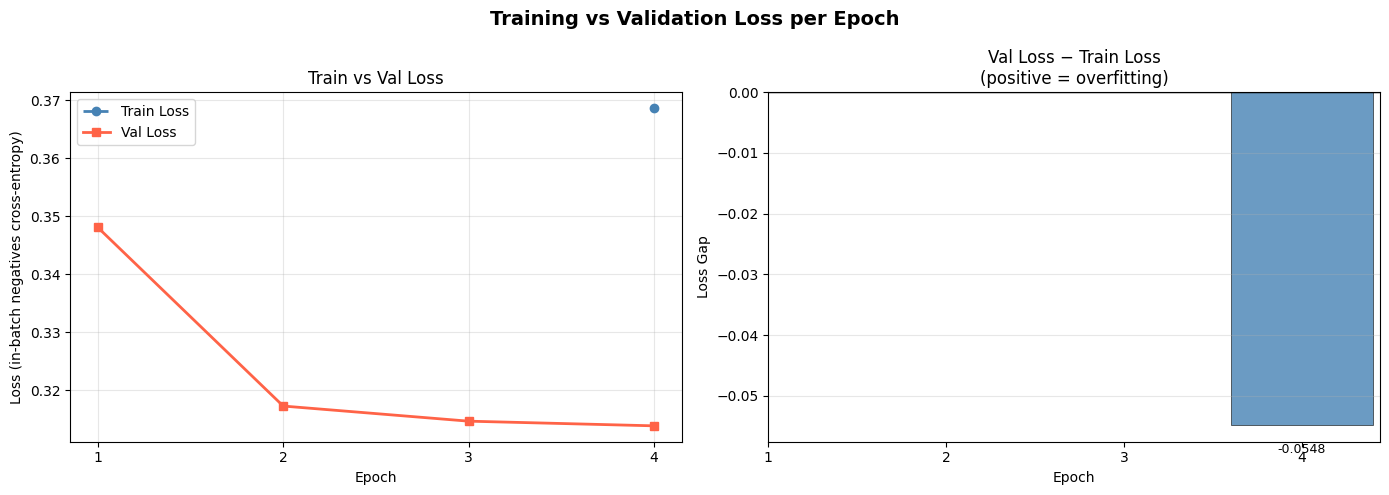

Saved: loss_per_epoch.png


In [72]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training vs Validation Loss per Epoch", fontsize=14, fontweight="bold")

axes[0].plot(eval_epochs, train_loss_per_epoch, marker="o", linestyle="--",
             color="steelblue", linewidth=2, label="Train Loss")
axes[0].plot(eval_epochs, eval_loss, marker="s", linestyle="-",
             color="tomato", linewidth=2, label="Val Loss")
axes[0].set_title("Train vs Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (in-batch negatives cross-entropy)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(eval_epochs)

gap = [e - t if not np.isnan(t) else float("nan")
       for e, t in zip(eval_loss, train_loss_per_epoch)]
axes[1].bar(eval_epochs, gap,
            color=["tomato" if g > 0 else "steelblue" for g in gap],
            alpha=0.8, edgecolor="black", linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Val Loss − Train Loss\n(positive = overfitting)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Gap")
axes[1].set_xticks(eval_epochs)
axes[1].grid(True, alpha=0.3, axis="y")
for ep, g in zip(eval_epochs, gap):
    if not np.isnan(g):
        axes[1].text(ep, g + (0.001 if g >= 0 else -0.003),
                     f"{g:+.4f}", ha="center",
                     va="bottom" if g >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.savefig("/content/loss_per_epoch.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: loss_per_epoch.png")